<font size = 10>\
    Projet 4 - Build a scoring model

Import usefull package

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score
from sklearn.datasets import make_classification
from sklearn.dummy import DummyClassifier
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
import imblearn
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import SGDClassifier
from sklearn.kernel_ridge import KernelRidge
from sklearn.pipeline import make_pipeline

# Load dataset

## Working with the Loan appplication data set

### Training data

In [3]:
app_train = pd.read_csv('data/application_train.csv')
print('Training data shape: ', app_train.shape)

Training data shape:  (307511, 122)


### Kaggle Testing dataset

In [4]:
app_test = pd.read_csv('data/application_test.csv')
print('Testing data shape: ', app_test.shape)

Testing data shape:  (48744, 121)


# Exploratory Data Analysis

## Distribution of the target

In [114]:
app_train['TARGET'].value_counts()

0    282686
1     24825
Name: TARGET, dtype: int64

## Missing values

In [115]:
(app_train.isna().sum(axis = 0) / app_train.shape[0]).sort_values(ascending=False)[0:20]

COMMONAREA_MEDI             0.698723
COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_MEDI    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_MEDI       0.683550
LIVINGAPARTMENTS_MODE       0.683550
LIVINGAPARTMENTS_AVG        0.683550
FLOORSMIN_MEDI              0.678486
FLOORSMIN_MODE              0.678486
FLOORSMIN_AVG               0.678486
YEARS_BUILD_MEDI            0.664978
YEARS_BUILD_AVG             0.664978
YEARS_BUILD_MODE            0.664978
OWN_CAR_AGE                 0.659908
LANDAREA_MODE               0.593767
LANDAREA_AVG                0.593767
LANDAREA_MEDI               0.593767
dtype: float64

## Feature types

In [116]:
app_train.dtypes.value_counts()

float64    65
int64      41
object     16
dtype: int64

### Encoding Categorical Variables

Encode with labelEncoder for 2 unique categories or use get_dumies

In [117]:
from sklearn.preprocessing import LabelEncoder


# Create a label encoder object
le = LabelEncoder()
le_count = 0

# Iterate through the columns
for col in app_train:
    if app_train[col].dtype == 'object':
        # If 2 or fewer unique categories
        if len(list(app_train[col].unique())) <= 2:
            # Train on the training data
            le.fit(app_train[col])
            # Transform both training and testing data
            app_train[col] = le.transform(app_train[col])
            app_test[col] = le.transform(app_test[col])
            
            # Keep track of how many columns were label encoded
            le_count += 1
            
print('%d columns were label encoded.' % le_count)

3 columns were label encoded.


In [118]:
# one-hot encoding of categorical variables
app_train = pd.get_dummies(app_train)
app_test = pd.get_dummies(app_test)

print('Training Features shape: ', app_train.shape)
print('Testing Features shape: ', app_test.shape)

Training Features shape:  (307511, 243)
Testing Features shape:  (48744, 239)


In [119]:
train_labels = app_train['TARGET']

# Align the training and testing data, keep only columns present in both dataframes
app_train, app_test = app_train.align(app_test, join = 'inner', axis = 1)

# Add the target back in
app_train['TARGET'] = train_labels

print('Training Features shape: ', app_train.shape)
print('Testing Features shape: ', app_test.shape)

Training Features shape:  (307511, 240)
Testing Features shape:  (48744, 239)


In [120]:
app_train.to_pickle('data/app_train_encode_categ')
app_test.to_pickle('data/app_test_encode_categ')

### Outliers in numerical features

In [121]:
app_train=pd.read_pickle('data/app_train_encode_categ')
app_test=pd.read_pickle('data/app_test_encode_categ')

Print the describe function on the numerical columns to check for outliers

In [122]:
app_num=app_train.select_dtypes(include=['float64','int64'])

In [123]:
def show_describe(i):
    return app_num.describe().iloc[:,(i-1)*10:i*10]

In [124]:
widgets.interact(show_describe, i=10)

interactive(children=(IntSlider(value=10, description='i', max=30, min=-10), Output()), _dom_classes=('widget-…

<function __main__.show_describe(i)>

In [125]:
suspected_outliers=['DAYS_EMPLOYED',
                    'OBS_30_CNT_SOCIAL_CIRCLE',
                    'DEF_30_CNT_SOCIAL_CIRCLE',
                    'OBS_60_CNT_SOCIAL_CIRCLE',
                    'DEF_60_CNT_SOCIAL_CIRCLE',
                    'AMT_REQ_CREDIT_BUREAU_HOUR',
                    'AMT_REQ_CREDIT_BUREAU_DAY',
                    'AMT_REQ_CREDIT_BUREAU_WEEK',
                    'AMT_REQ_CREDIT_BUREAU_MON',
                    'AMT_REQ_CREDIT_BUREAU_QRT',
                    'AMT_REQ_CREDIT_BUREAU_YEAR',
                    'HOUR_APPR_PROCESS_START'
                   ]

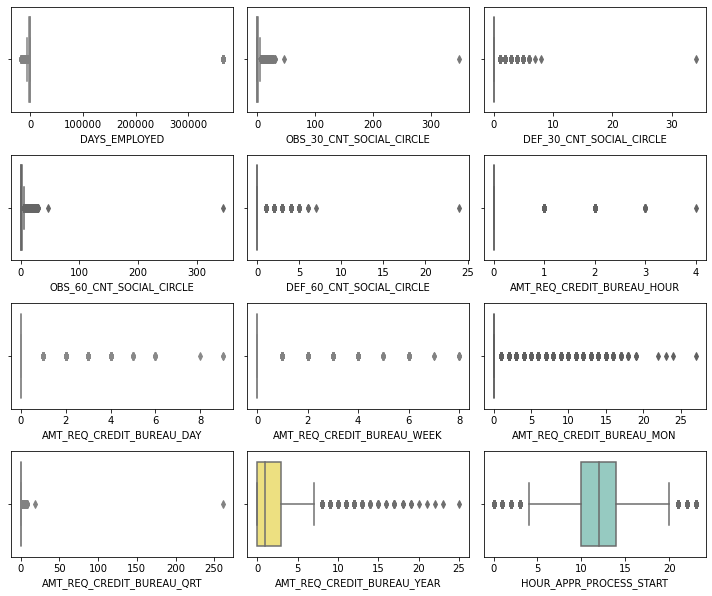

In [126]:
i=0
colors=sns.color_palette("Set3", 14)
plt.figure(figsize=(10,10))
for col in suspected_outliers:
    i+=1
    plt.subplot(5,3,i)
    sns.boxplot(x=app_train[col],color=colors[i%12])
plt.tight_layout()

#### DAYS_EMPLOYED

In [127]:
app_train[app_train['DAYS_EMPLOYED']>200000].shape

(55374, 240)

<AxesSubplot:xlabel='DAYS_EMPLOYED'>

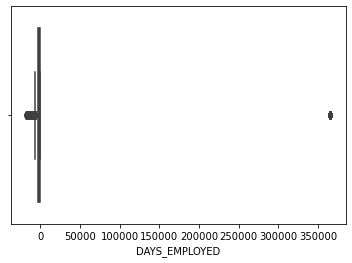

In [128]:
sns.boxplot(x=app_train['DAYS_EMPLOYED'])

In [129]:
# Create an anomalous flag column
app_train['DAYS_EMPLOYED_ANOM'] = app_train["DAYS_EMPLOYED"] == 365243

# Replace the anomalous values with nan
app_train['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace = True)

# Apply the same steps to the test data
app_test['DAYS_EMPLOYED_ANOM'] = app_test["DAYS_EMPLOYED"] == 365243
app_test["DAYS_EMPLOYED"].replace({365243: np.nan}, inplace = True)



#### Social circle features

In [130]:
app_train[app_train['OBS_30_CNT_SOCIAL_CIRCLE']>100].shape

(1, 241)

In [131]:
app_train.drop(index=app_train[app_train['OBS_30_CNT_SOCIAL_CIRCLE']>100].index,inplace=True)

<AxesSubplot:xlabel='DEF_30_CNT_SOCIAL_CIRCLE'>

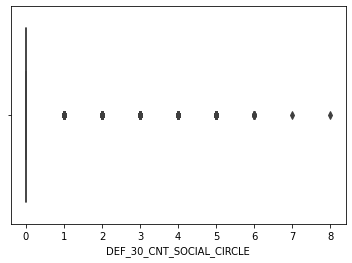

In [132]:
sns.boxplot(x=app_train['DEF_30_CNT_SOCIAL_CIRCLE'])

In [133]:
app_train[(app_train['DEF_30_CNT_SOCIAL_CIRCLE']>1.5) & (app_train['DEF_30_CNT_SOCIAL_CIRCLE']<2.5)].shape

(5323, 241)

In [134]:
app_train[(app_train['OBS_30_CNT_SOCIAL_CIRCLE']>15) & (app_train['OBS_30_CNT_SOCIAL_CIRCLE']<25)].shape

(418, 241)

<AxesSubplot:xlabel='DEF_60_CNT_SOCIAL_CIRCLE', ylabel='OBS_60_CNT_SOCIAL_CIRCLE'>

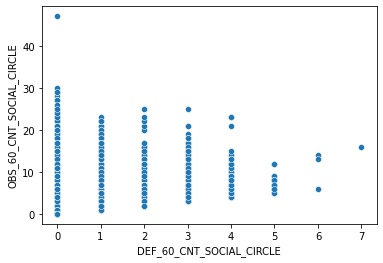

In [135]:
sns.scatterplot(x=app_train['DEF_60_CNT_SOCIAL_CIRCLE'],y=app_train['OBS_60_CNT_SOCIAL_CIRCLE'])

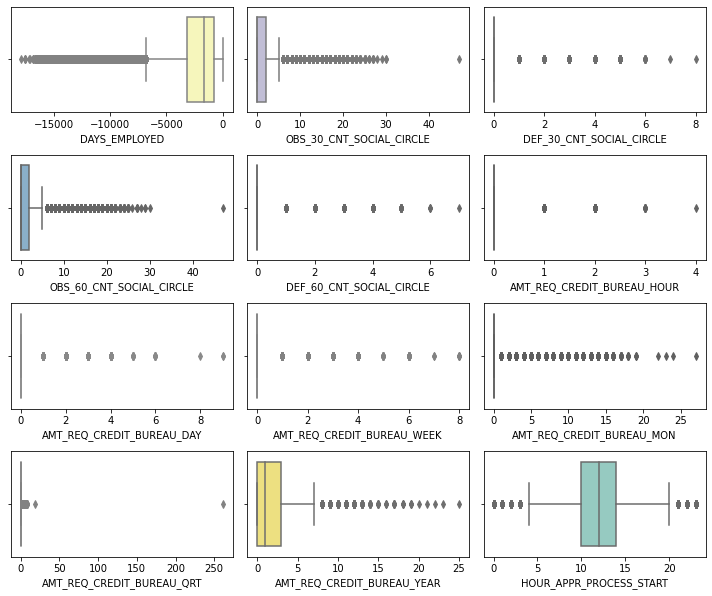

In [45]:
i=0
colors=sns.color_palette("Set3", 14)
plt.figure(figsize=(10,10))
for col in suspected_outliers:
    i+=1
    plt.subplot(5,3,i)
    sns.boxplot(x=app_train[col],color=colors[i%12])
plt.tight_layout()

#### Amount of request features

<AxesSubplot:xlabel='AMT_REQ_CREDIT_BUREAU_QRT'>

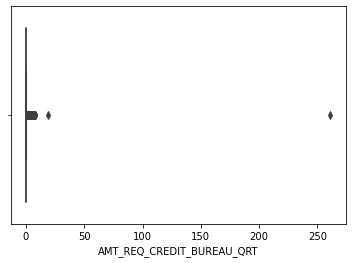

In [136]:
sns.boxplot(x=app_train['AMT_REQ_CREDIT_BUREAU_QRT'])

In [137]:
app_train[app_train['AMT_REQ_CREDIT_BUREAU_QRT']>15].shape

(2, 241)

In [138]:
app_train.drop(index=app_train[app_train['AMT_REQ_CREDIT_BUREAU_QRT']>15].index,inplace=True)

<AxesSubplot:xlabel='AMT_REQ_CREDIT_BUREAU_QRT'>

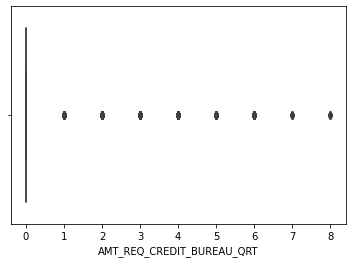

In [139]:
sns.boxplot(x=app_train['AMT_REQ_CREDIT_BUREAU_QRT'])

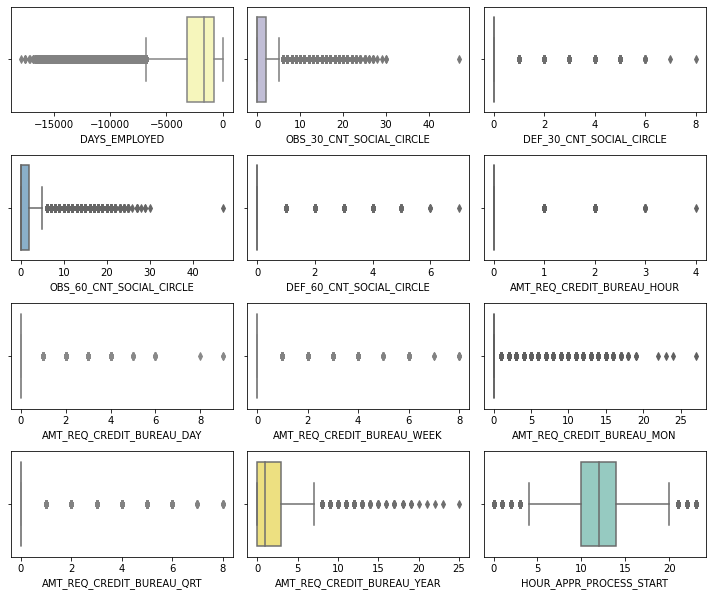

In [68]:
i=0
colors=sns.color_palette("Set3", 14)
plt.figure(figsize=(10,10))
for col in suspected_outliers:
    i+=1
    plt.subplot(5,3,i)
    sns.boxplot(x=app_train[col],color=colors[i%12])
plt.tight_layout()

In [140]:
app_train.to_pickle('data/app_train_outliers')
app_test.to_pickle('data/app_test_outliers')

## Correlations

In [5]:
app_train=pd.read_pickle('data/app_train_outliers')
app_test=pd.read_pickle('data/app_test_outliers')
print('app_train shape :', app_train.shape)
print('app_test shape :',app_test.shape)

app_train shape : (307508, 241)
app_test shape : (48744, 240)


In [142]:
correlation_matrix=app_train.corr()

In [50]:
#correlation_matrix.to_pickle('data/correlation_matrix')

In [51]:
#correlation_matrix=pd.read_pickle('data/correlation_matrix')

In [143]:
np.fill_diagonal(correlation_matrix.values,0)

In [144]:
correlation_abs_matrix = correlation_matrix.abs()

In [145]:
corr_max_abs = pd.DataFrame(correlation_abs_matrix.idxmax(axis=0),columns=['feature'])

In [146]:
corr_max_abs['corr_coef']=correlation_abs_matrix.max(axis=0)

In [147]:
corr_max_abs.sort_values('corr_coef',ascending=False,inplace=True)

In [148]:
correlation_abs_matrix['TARGET'].sort_values(ascending=False).head(20)

EXT_SOURCE_3                                         0.178920
EXT_SOURCE_2                                         0.160448
EXT_SOURCE_1                                         0.155319
DAYS_BIRTH                                           0.078251
DAYS_EMPLOYED                                        0.074954
REGION_RATING_CLIENT_W_CITY                          0.060897
REGION_RATING_CLIENT                                 0.058903
NAME_INCOME_TYPE_Working                             0.057472
NAME_EDUCATION_TYPE_Higher education                 0.056585
DAYS_LAST_PHONE_CHANGE                               0.055208
CODE_GENDER_M                                        0.054723
CODE_GENDER_F                                        0.054714
DAYS_ID_PUBLISH                                      0.051451
REG_CITY_NOT_WORK_CITY                               0.051003
NAME_EDUCATION_TYPE_Secondary / secondary special    0.049815
NAME_INCOME_TYPE_Pensioner                           0.046206
DAYS_EMP

# Baseline

In [29]:
def show_score(y_test,y_pred_d_cls_prob,y_pred_d_cls):
    a=roc_auc_score(y_test,y_pred_d_cls_prob)
    b=f1_score(y_test,y_pred_d_cls)
    c=accuracy_score(y_test,y_pred_d_cls)
    d=precision_score(y_test,y_pred_d_cls)
    e=recall_score(y_test,y_pred_d_cls)
    print('ROC AUC   :',a)
    print('F1        :',b)
    print('Accuracy  :',c)
    print('Precision :',d)
    print('Recall    :',e)

## Test and Train split

In [6]:
X = app_train.drop( columns = ['TARGET'])
y = app_train['TARGET']
features = app_test.columns

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

## Imputation of data

### Using SimpleImputer

In [9]:
simple_imputer = SimpleImputer(strategy = 'median')

## Standardization

In [10]:
scaler = StandardScaler()

## Dummy classifier

In [32]:
pipeline_basic = make_pipeline(simple_imputer,scaler)
pipeline_basic.fit(X_train,y_train)
X_train_std = pipeline_basic.transform(X_train)
X_test_std = pipeline_basic.transform(X_test)

In [33]:
dummy_cls = DummyClassifier(strategy='stratified')
dummy_cls.fit(X_train_std,y_train)
y_prob_dummy = dummy_cls.predict_proba(X_test_std)[0:,1]
y_pred_dummy = dummy_cls.predict(X_test_std)

In [34]:
show_score(y_test,y_prob_dummy,y_pred_dummy)

ROC AUC   : 0.5003723225963631
F1        : 0.08217344753747324
Accuracy  : 0.8513235198473779
Precision : 0.08201977023777718
Recall    : 0.08232770179672834


# Class Unbalance

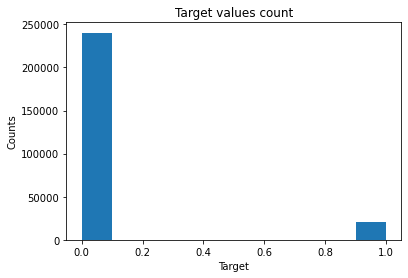

In [36]:
plt.hist(y_train)
plt.xlabel('Target')
plt.ylabel('Counts')
plt.title('Target values count')
plt.show()

## Class unbalanced strategy

### Over sampling

In [37]:
X_up,y_up = resample(X_train_std[y_train == 1],
                     y_train[y_train == 1],
                     replace=True,
                     n_samples=X_train_std[y_train == 0].shape[0])

In [74]:
X_train_up = np.vstack((X_train_std[y_train == 0], X_up))
y_train_up = np.hstack((y_train[y_train == 0], y_up))

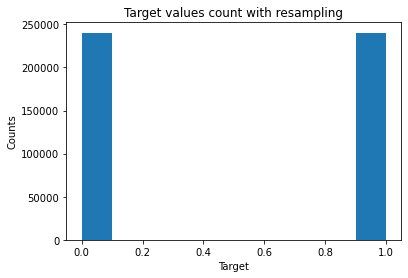

In [75]:
plt.hist(y_train_up)
plt.xlabel('Target')
plt.ylabel('Counts')
plt.title('Target values count with resampling')
plt.show()

### Data augmentation Using SMOTE

In [78]:
oversample = imblearn.over_sampling.SMOTE(sampling_strategy = 0.4)
undersample = imblearn.under_sampling.RandomUnderSampler(sampling_strategy = 0.7)

In [79]:
pipeline_smote = imblearn.pipeline.Pipeline(steps = [('over',oversample),('under',undersample)])

In [80]:
X_train_smote,y_train_smote = pipeline_smote.fit_resample(X_train_std,y_train)

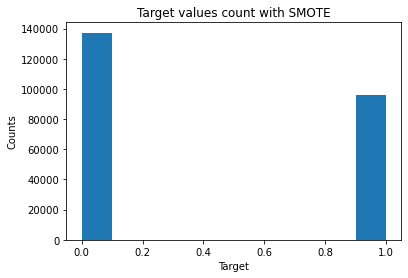

In [81]:
plt.hist(y_train_smote)
plt.xlabel('Target')
plt.ylabel('Counts')
plt.title('Target values count with SMOTE')
plt.show()

In [82]:
X_train_smote.shape

(233419, 240)

In [83]:
X_train_std.shape

(261381, 240)

## Strategy comparison

In [65]:
lg = LogisticRegression(C=0.01,max_iter=200)
lg.fit(X_train_std,y_train)
log_reg_prob = lg.predict_proba(X_test_std)[:,1]
log_reg_pred = lg.predict(X_test_std)
print('logistic regression with basic preprocessing')
show_score(y_test,log_reg_prob,log_reg_pred)

logistic regression with basic preprocessing
ROC AUC   : 0.7464920241245055
F1        : 0.019832985386221295
Accuracy  : 0.9185726364168492
Precision : 0.36893203883495146
Recall    : 0.010190399570930545


In [68]:
lg = LogisticRegression(C=0.01, class_weight='balanced',max_iter=200)
lg.fit(X_train_std,y_train)
log_reg_prob = lg.predict_proba(X_test_std)[:,1]
log_reg_pred = lg.predict(X_test_std)
print('logistic regression with basic preprocessing and balanced option')
show_score(y_test,log_reg_prob,log_reg_pred)

logistic regression with basic preprocessing and balanced option
ROC AUC   : 0.7462526662035989
F1        : 0.25834662276866094
Accuracy  : 0.6874498666724478
Precision : 0.15983450031826862
Recall    : 0.6733708769107


In [76]:
lg = LogisticRegression(C=0.01,max_iter=200)
lg.fit(X_train_up,y_train_up)
log_reg_prob = lg.predict_proba(X_test_std)[:,1]
log_reg_pred = lg.predict(X_test_std)
print('logistic regression with oversampling')
show_score(y_test,log_reg_prob,log_reg_pred)

logistic regression with oversampling
ROC AUC   : 0.7461883849745692
F1        : 0.2593050829982472
Accuracy  : 0.6885121512346348
Precision : 0.16050800944540175
Recall    : 0.6744435505497453


In [84]:
lg = LogisticRegression(C=0.01,max_iter=200)
lg.fit(X_train_smote,y_train_smote)
log_reg_prob = lg.predict_proba(X_test_std)[:,1]
log_reg_pred = lg.predict(X_test_std)
print('logistic regression with smote')
show_score(y_test,log_reg_prob,log_reg_pred)

logistic regression with smote
ROC AUC   : 0.7396308836853077
F1        : 0.2817080045095829
Accuracy  : 0.7790014525115442
Precision : 0.1910541909586161
Recall    : 0.5360686511128989


# Feature Selection

## Logistic regression

### With unbalanced dataset

In [96]:
lg = LogisticRegression(C=0.01)
lg.fit(X_train_scaled,y_train)
log_reg_pred_prob = lg.predict_proba(X_test_scaled)[:,1]
log_reg_pred = lg.predict(X_test_scaled)

In [97]:
show_score(y_test,log_reg_pred_prob,log_reg_pred)

ROC AUC   : 0.7461794413892254
F1        : 0.013175230566534916
Accuracy  : 0.9188111084614218
Precision : 0.3787878787878788
Recall    : 0.006704210244033253


### With balanced option

In [182]:
lg = LogisticRegression(C=0.001,class_weight='balanced')
lg.fit(X_train_scaled,y_train)
log_reg_pred_prob = lg.predict_proba(X_test_scaled)[:,1]
log_reg_pred = lg.predict(X_test_scaled)
show_score(y_test,log_reg_pred_prob,log_reg_pred)

ROC AUC   : 0.7463105718074332
F1        : 0.25736465991465735
Accuracy  : 0.6868428469226266
Precision : 0.1592036636560234
Recall    : 0.6712255296326093


<AxesSubplot:xlabel='importance', ylabel='feature'>

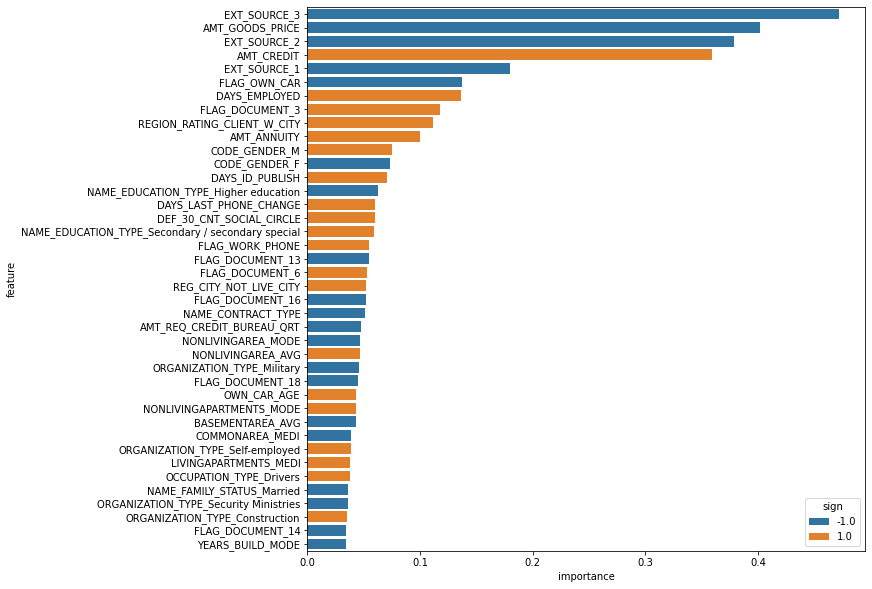

In [184]:
lg_coef=pd.DataFrame(lg.coef_.reshape(240,),columns=['coeff'])
lg_coef['importance']=np.abs(lg_coef['coeff'])
lg_coef['sign']=np.sign(lg_coef['coeff'])
lg_coef['feature']=app_test.columns
lg_coef = lg_coef.sort_values(by='importance',ascending=False).head(40)
plt.figure(figsize=(10,10))
sns.barplot(data=lg_coef,x ='importance',y='feature',hue='sign',dodge=False)

### With balanced dataset using oversampling

In [95]:
lg = LogisticRegression(C=0.01)
lg.fit(X_train_up,y_train_up)
log_reg_pred_prob = lg.predict_proba(X_test_scaled)[:,1]
log_reg_pred = lg.predict(X_test_scaled)

In [82]:
show_score(y_test,log_reg_pred_prob,log_reg_pred)

ROC AUC   : 0.5397907860097176
F1        : 0.1495908215661104
Accuracy  : 0.08084202311010905
Precision : 0.08084202311010905
Recall    : 1.0


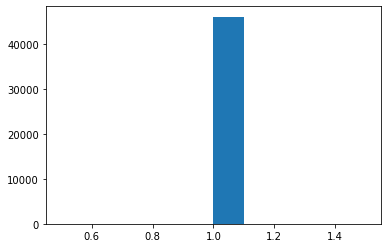

In [83]:
plt.hist(log_reg_pred)
plt.show()

### With balanced dataset using smote

In [99]:
lg = LogisticRegression(C=0.001)
lg.fit(X_train_smote,y_train_smote)
log_reg_pred_prob = lg.predict_proba(X_test_scaled)[:,1]
log_reg_pred = lg.predict(X_test_scaled)

In [100]:
show_score(y_test,log_reg_pred_prob,log_reg_pred)

ROC AUC   : 0.7372218144900275
F1        : 0.2551096049984115
Accuracy  : 0.6950159342684328
Precision : 0.15893646499967012
Recall    : 0.6460176991150443


In [101]:
log_reg_pred

array([1, 1, 1, ..., 0, 1, 0], dtype=int64)

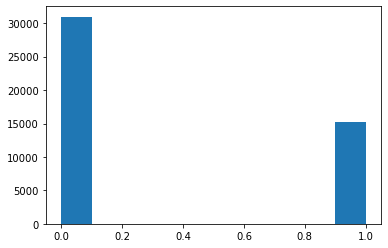

In [102]:
plt.hist(log_reg_pred)
plt.show()

<AxesSubplot:xlabel='importance', ylabel='feature'>

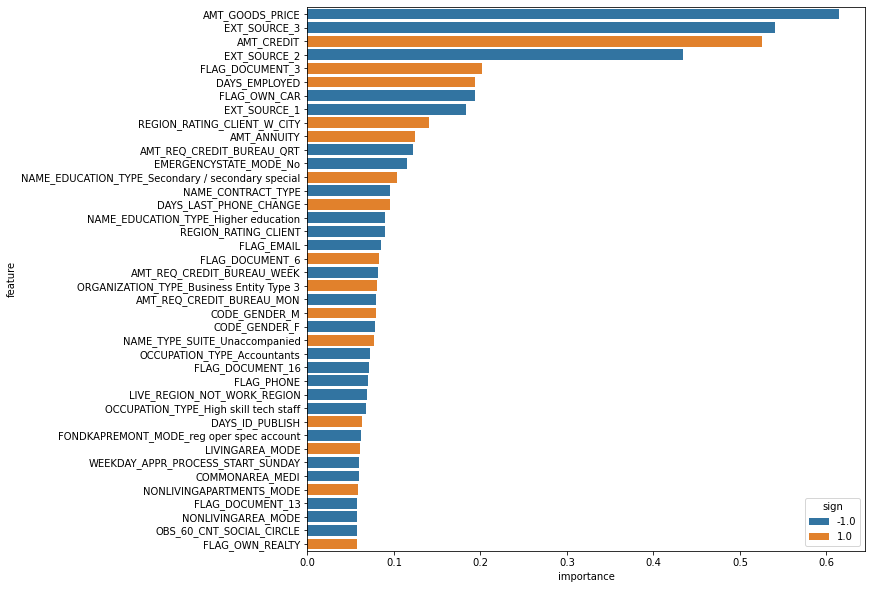

In [103]:
lg_coef=pd.DataFrame(lg.coef_.reshape(240,),columns=['coeff'])
lg_coef['importance']=np.abs(lg_coef['coeff'])
lg_coef['sign']=np.sign(lg_coef['coeff'])
lg_coef['feature']=app_test.columns
lg_coef = lg_coef.sort_values(by='importance',ascending=False).head(40)
plt.figure(figsize=(10,10))
sns.barplot(data=lg_coef,x ='importance',y='feature',hue='sign',dodge=False)

In [108]:
lg_coef['feature'][0:15]

8                                        AMT_GOODS_PRICE
33                                          EXT_SOURCE_3
6                                             AMT_CREDIT
32                                          EXT_SOURCE_2
83                                       FLAG_DOCUMENT_3
11                                         DAYS_EMPLOYED
2                                           FLAG_OWN_CAR
31                                          EXT_SOURCE_1
23                           REGION_RATING_CLIENT_W_CITY
7                                            AMT_ANNUITY
106                            AMT_REQ_CREDIT_BUREAU_QRT
237                               EMERGENCYSTATE_MODE_No
128    NAME_EDUCATION_TYPE_Secondary / secondary special
1                                     NAME_CONTRACT_TYPE
81                                DAYS_LAST_PHONE_CHANGE
Name: feature, dtype: object

## Random forest

### Using balanced class option

In [109]:
rdf = RandomForestClassifier(n_estimators= 200, class_weight="balanced",n_jobs=4)
rdf.fit(X_train_scaled,y_train)
rdf_prob = rdf.predict_proba(X_test_scaled)[:,1]
rdf_pred = rdf.predict(X_test_scaled)

In [110]:
show_score(y_test,rdf_prob,rdf_pred)

ROC AUC   : 0.7334885475492166
F1        : 0.0032085561497326204
Accuracy  : 0.9191796561666703
Precision : 0.5454545454545454
Recall    : 0.0016090104585679806


<AxesSubplot:xlabel='importance', ylabel='feature'>

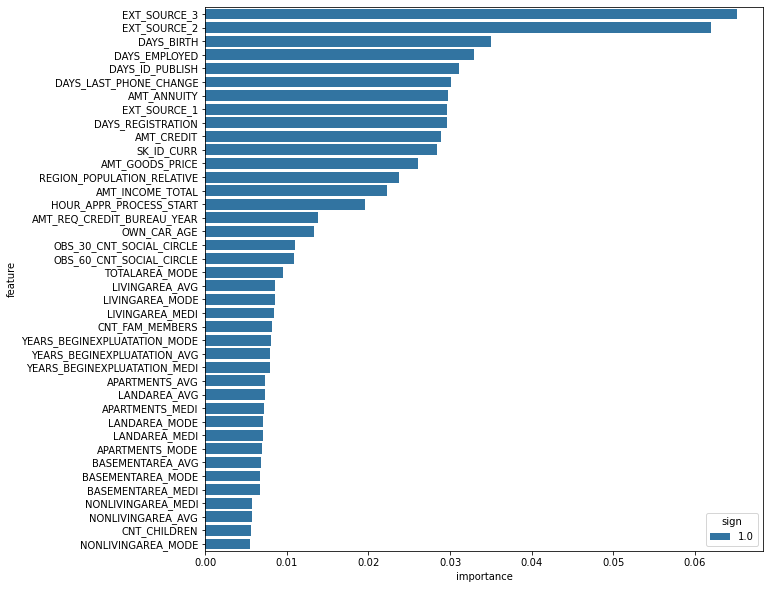

In [111]:
rdf_coef=pd.DataFrame(rdf.feature_importances_.reshape(240,),columns=['coeff'])
rdf_coef['importance']=np.abs(rdf_coef['coeff'])
rdf_coef['sign']=np.sign(rdf_coef['coeff'])
rdf_coef['feature']=app_test.columns
rdf_coef = rdf_coef.sort_values(by='importance',ascending=False).head(40)
plt.figure(figsize=(10,10))
sns.barplot(data=rdf_coef,x ='importance',y='feature',hue='sign',dodge=False)

In [ ]:
rdf_coef['feature'][0:15]

### Using SMOTE

In [115]:
rdf = RandomForestClassifier(n_estimators= 200,n_jobs=4)
rdf.fit(X_train_smote,y_train_smote)
rdf_prob = rdf.predict_proba(X_test_scaled)[:,1]
rdf_pred = rdf.predict(X_test_scaled)

In [116]:
show_score(y_test,rdf_prob,rdf_pred)

ROC AUC   : 0.7125891374703828
F1        : 0.015175300889586603
Accuracy  : 0.9183992022026145
Precision : 0.3118279569892473
Recall    : 0.007776883883078573


<AxesSubplot:xlabel='importance', ylabel='feature'>

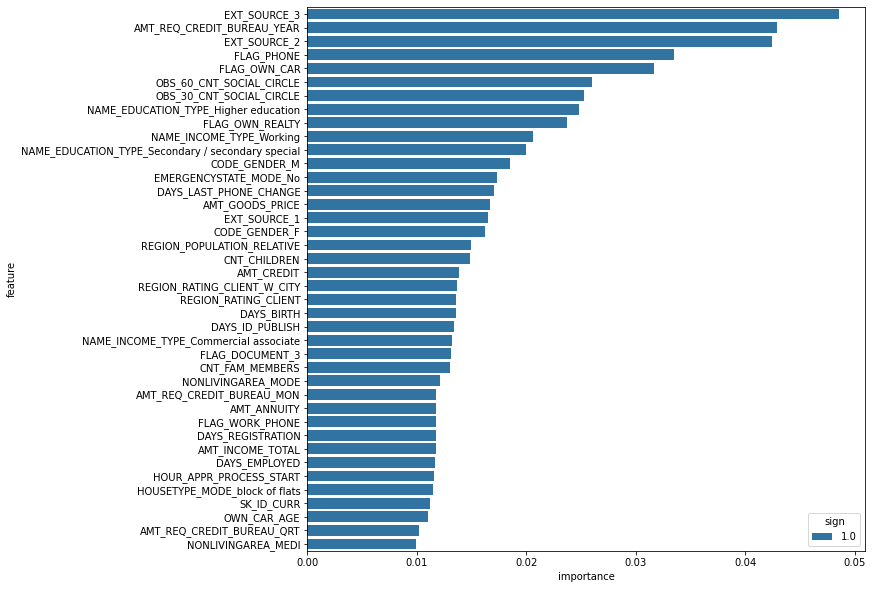

In [117]:
rdf_coef=pd.DataFrame(rdf.feature_importances_.reshape(240,),columns=['coeff'])
rdf_coef['importance']=np.abs(rdf_coef['coeff'])
rdf_coef['sign']=np.sign(rdf_coef['coeff'])
rdf_coef['feature']=app_test.columns
rdf_coef = rdf_coef.sort_values(by='importance',ascending=False).head(40)
plt.figure(figsize=(10,10))
sns.barplot(data=rdf_coef,x ='importance',y='feature',hue='sign',dodge=False)

In [118]:
rdf_coef['feature'][0:15]

33                                          EXT_SOURCE_3
107                           AMT_REQ_CREDIT_BUREAU_YEAR
32                                          EXT_SOURCE_2
19                                            FLAG_PHONE
2                                           FLAG_OWN_CAR
79                              OBS_60_CNT_SOCIAL_CIRCLE
77                              OBS_30_CNT_SOCIAL_CIRCLE
125                 NAME_EDUCATION_TYPE_Higher education
3                                        FLAG_OWN_REALTY
123                             NAME_INCOME_TYPE_Working
128    NAME_EDUCATION_TYPE_Secondary / secondary special
109                                        CODE_GENDER_M
237                               EMERGENCYSTATE_MODE_No
81                                DAYS_LAST_PHONE_CHANGE
8                                        AMT_GOODS_PRICE
Name: feature, dtype: object

# Elasticnet Regression

In [119]:
elastic = ElasticNet(alpha=0.01)
elastic.fit(X_train_smote, y_train_smote)

ElasticNet(alpha=0.01)

In [121]:
elastic_prob = elastic.predict(X_test_scaled)
elastic_pred = np.array([0 if x < 0.5 else 1 for x in elastic_prob])

In [123]:
elastic_prob.max()

1.2340387591101893

In [124]:
show_score(y_test,elastic_prob,elastic_pred)

ROC AUC   : 0.7404818968233841
F1        : 0.2564129465456644
Accuracy  : 0.6926962516530448
Precision : 0.15938437459240903
Recall    : 0.6554035934566907


<AxesSubplot:xlabel='importance', ylabel='feature'>

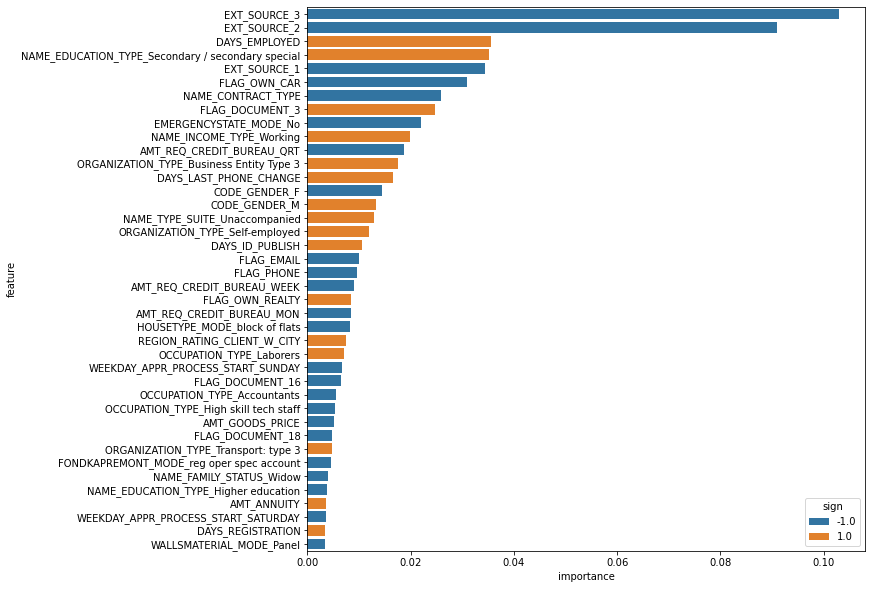

In [125]:
elastic_coef=pd.DataFrame(elastic.coef_,columns=['coeff'])
elastic_coef['importance']=np.abs(elastic_coef['coeff'])
elastic_coef['sign']=np.sign(elastic_coef['coeff'])
elastic_coef['feature']=app_test.columns
elastic_coef = elastic_coef.sort_values(by='importance',ascending=False).head(40)
plt.figure(figsize=(10,10))
sns.barplot(data=elastic_coef,x ='importance',y='feature',hue='sign',dodge=False)

In [127]:
elastic_coef['feature'][0:15]

33                                          EXT_SOURCE_3
32                                          EXT_SOURCE_2
11                                         DAYS_EMPLOYED
128    NAME_EDUCATION_TYPE_Secondary / secondary special
31                                          EXT_SOURCE_1
2                                           FLAG_OWN_CAR
1                                     NAME_CONTRACT_TYPE
83                                       FLAG_DOCUMENT_3
237                               EMERGENCYSTATE_MODE_No
123                             NAME_INCOME_TYPE_Working
106                            AMT_REQ_CREDIT_BUREAU_QRT
170             ORGANIZATION_TYPE_Business Entity Type 3
81                                DAYS_LAST_PHONE_CHANGE
108                                        CODE_GENDER_F
109                                        CODE_GENDER_M
Name: feature, dtype: object

# SGD Classifier

In [128]:
sgd = SGDClassifier(class_weight='balanced',loss='modified_huber')

In [129]:
sgd.fit(X_train_scaled,y_train)

SGDClassifier(class_weight='balanced', loss='modified_huber')

In [130]:
sgd_prob = sgd.predict_proba(X_test_scaled)[:,1]
sgd_pred = sgd.predict(X_test_scaled)

In [131]:
show_score(y_test,sgd_prob,sgd_pred)

ROC AUC   : 0.6963300313793345
F1        : 0.2213639954357939
Accuracy  : 0.6153662713811867
Precision : 0.1323398226373511
Recall    : 0.6763207294180745


<AxesSubplot:xlabel='importance', ylabel='feature'>

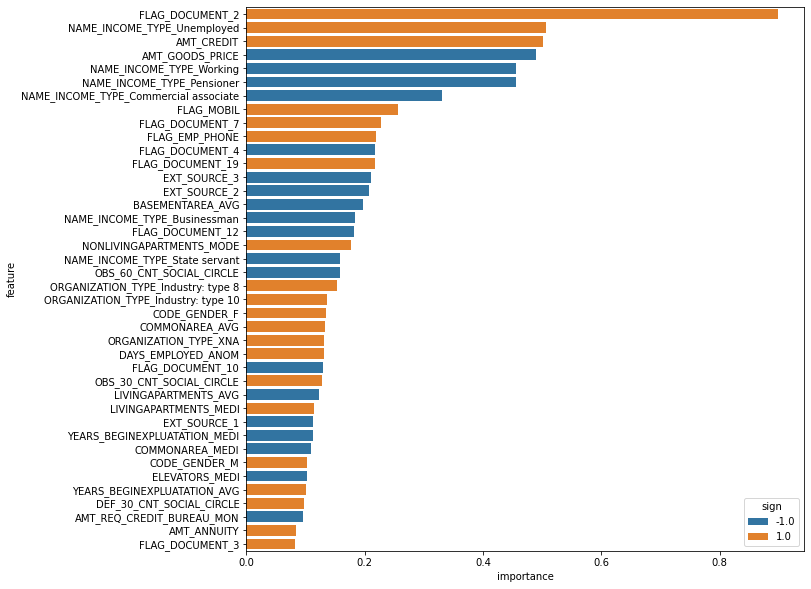

In [132]:
sgd_coef=pd.DataFrame(sgd.coef_.reshape(240,),columns=['coeff'])
sgd_coef['importance']=np.abs(sgd_coef['coeff'])
sgd_coef['sign']=np.sign(sgd_coef['coeff'])
sgd_coef['feature']=app_test.columns
sgd_coef = sgd_coef.sort_values(by='importance',ascending=False).head(40)
plt.figure(figsize=(10,10))
sns.barplot(data=sgd_coef,x ='importance',y='feature',hue='sign',dodge=False)

In [133]:
sgd_coef['feature'][0:15]

82                           FLAG_DOCUMENT_2
122              NAME_INCOME_TYPE_Unemployed
6                                 AMT_CREDIT
8                            AMT_GOODS_PRICE
123                 NAME_INCOME_TYPE_Working
119               NAME_INCOME_TYPE_Pensioner
118    NAME_INCOME_TYPE_Commercial associate
15                                FLAG_MOBIL
87                           FLAG_DOCUMENT_7
16                            FLAG_EMP_PHONE
84                           FLAG_DOCUMENT_4
99                          FLAG_DOCUMENT_19
33                              EXT_SOURCE_3
32                              EXT_SOURCE_2
35                          BASEMENTAREA_AVG
Name: feature, dtype: object

## Correlation with ridge regression

In [145]:
ridge = Ridge(alpha=3)

In [146]:
ridge.fit(X_train_smote,y_train_smote)

Ridge(alpha=3)

In [147]:
ridge_prob = ridge.predict(X_test_scaled)
ridge_pred = np.array([0 if x < 0.5 else 1 for x in ridge_prob])

In [148]:
show_score(y_test,ridge_prob,ridge_pred)

ROC AUC   : 0.7379718675791249
F1        : 0.2555223254105672
Accuracy  : 0.6923927417781343
Precision : 0.1588388780169602
Recall    : 0.6529900777688389


<AxesSubplot:xlabel='importance', ylabel='feature'>

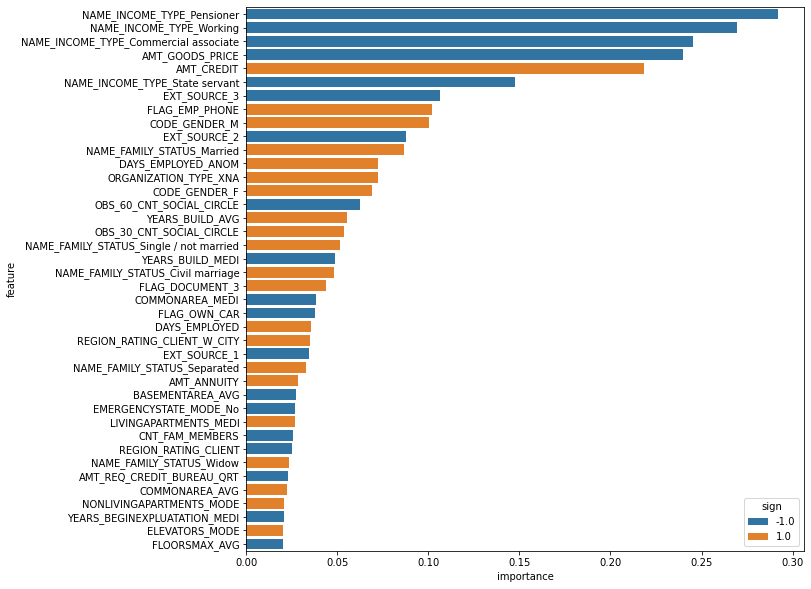

In [150]:
ridge_coef=pd.DataFrame(ridge.coef_,columns=['coeff'])
ridge_coef['importance']=np.abs(ridge_coef['coeff'])
ridge_coef['sign']=np.sign(ridge_coef['coeff'])
ridge_coef['feature']=app_test.columns
ridge_coef = ridge_coef.sort_values(by='importance',ascending=False).head(40)
plt.figure(figsize=(10,10))
sns.barplot(data=ridge_coef,x ='importance',y='feature',hue='sign',dodge=False)

# Feature Engineering

## Synthetic features using PCA

In [155]:
pca = PCA(n_components=2)

In [156]:
pca.fit(X_train_scaled)

PCA(n_components=2)

In [157]:
pca.explained_variance_ratio_

array([0.0782586 , 0.02861976])

In [208]:
PC1 = pd.DataFrame(pca.components_[0],columns=['coef'])
PC1['feature'] = features
PC2 = pd.DataFrame(pca.components_[1],columns=['coef'])
PC2['feature'] = features

In [209]:
PC1 = PC1.sort_values(by='coef',ascending=False)
PC2 = PC2.sort_values(by='coef',ascending=False)

<AxesSubplot:xlabel='coef', ylabel='feature'>

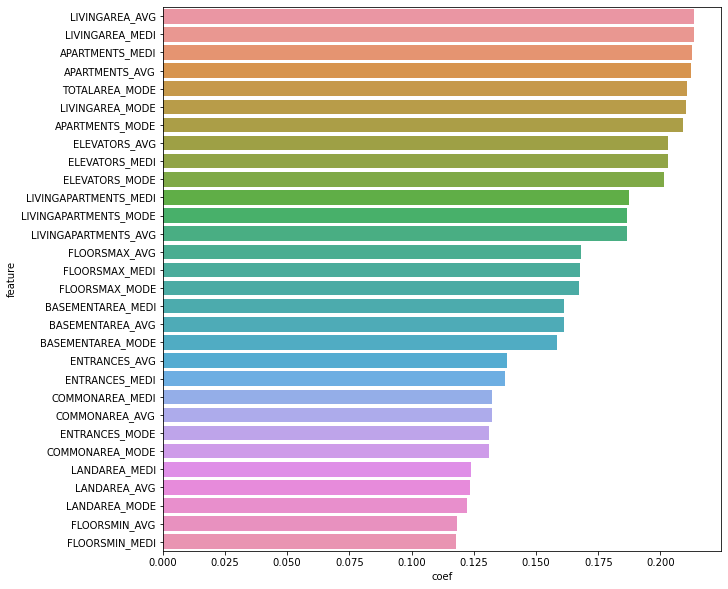

In [210]:
plt.figure(figsize=(10,10))
sns.barplot(data=PC1.head(30),x ='coef',y='feature')

<AxesSubplot:xlabel='coef', ylabel='feature'>

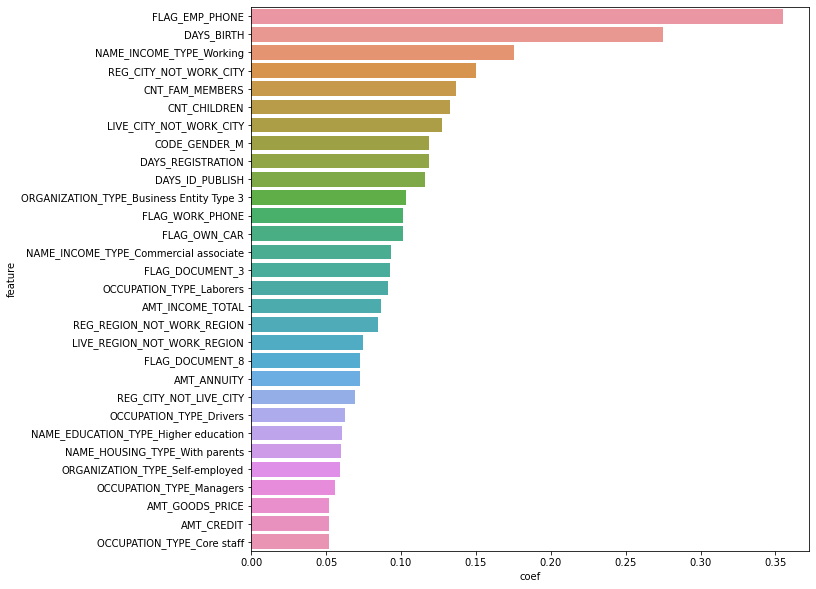

In [211]:
plt.figure(figsize=(10,10))
sns.barplot(data=PC2.head(30),x ='coef',y='feature')

In [170]:
X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [171]:
X_train_pca = np.hstack((X_train_scaled,X_train_pca))
X_test_pca = np.hstack((X_test_scaled,X_test_pca))

In [176]:
features_pca = np.hstack((features,['PC1','PC2']))

In [174]:
X_train_pca.shape

(261381, 242)

In [185]:
lg = LogisticRegression(C=0.001,class_weight='balanced')
lg.fit(X_train_pca,y_train)
log_reg_pred_prob = lg.predict_proba(X_test_pca)[:,1]
log_reg_pred = lg.predict(X_test_pca)

In [186]:
show_score(y_test,log_reg_pred_prob,log_reg_pred)

ROC AUC   : 0.7463100468303585
F1        : 0.2573778920308483
Accuracy  : 0.686864526199406
Precision : 0.15921379047134407
Recall    : 0.6712255296326093


<AxesSubplot:xlabel='importance', ylabel='feature'>

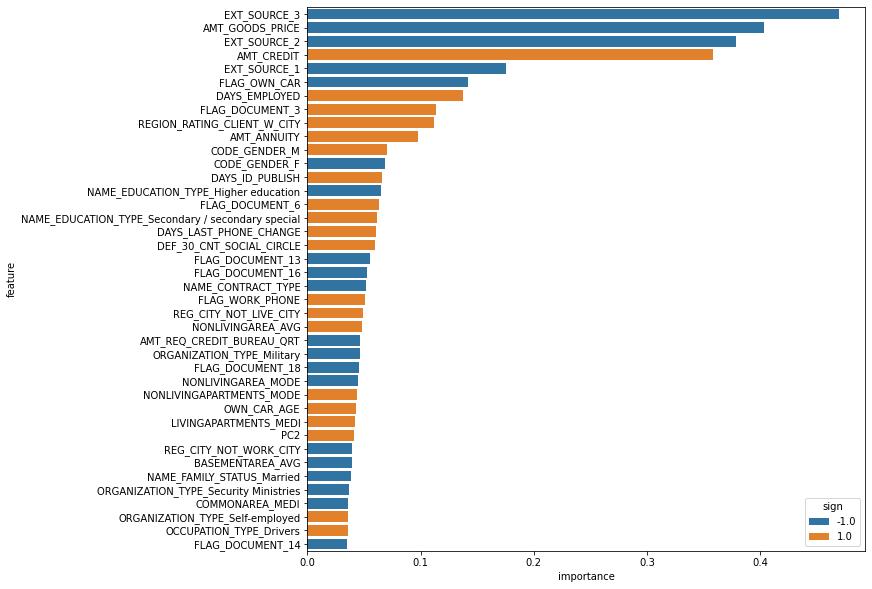

In [189]:
lg_coef=pd.DataFrame(lg.coef_.reshape(242,),columns=['coeff'])
lg_coef['importance']=np.abs(lg_coef['coeff'])
lg_coef['sign']=np.sign(lg_coef['coeff'])
lg_coef['feature']=features_pca
lg_coef = lg_coef.sort_values(by='importance',ascending=False).head(40)
plt.figure(figsize=(10,10))
sns.barplot(data=lg_coef,x ='importance',y='feature',hue='sign',dodge=False)

In [190]:
rdf = RandomForestClassifier(n_estimators= 200, class_weight="balanced",n_jobs=4)
rdf.fit(X_train_pca,y_train)
rdf_prob = rdf.predict_proba(X_test_pca)[:,1]
rdf_pred = rdf.predict(X_test_pca)

In [191]:
show_score(y_test,log_reg_pred_prob,log_reg_pred)

ROC AUC   : 0.7463100468303585
F1        : 0.2573778920308483
Accuracy  : 0.686864526199406
Precision : 0.15921379047134407
Recall    : 0.6712255296326093


<AxesSubplot:xlabel='importance', ylabel='feature'>

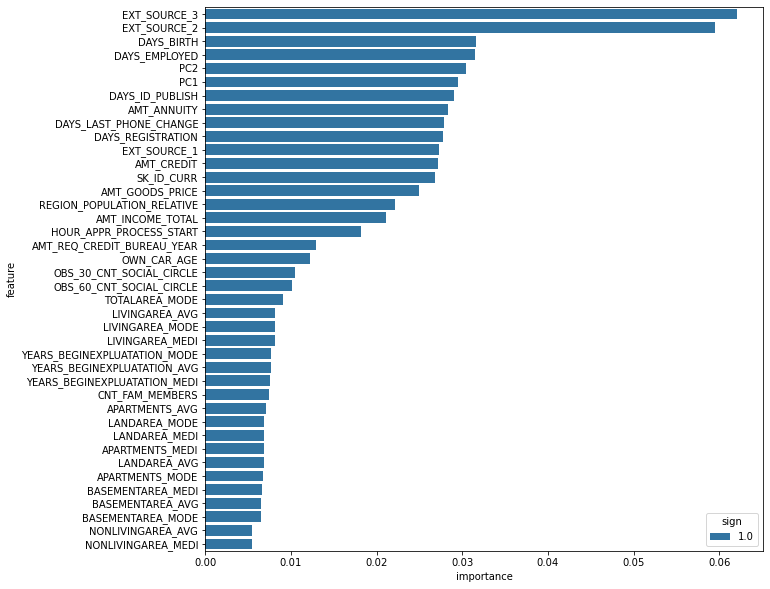

In [192]:
rdf_coef=pd.DataFrame(rdf.feature_importances_.reshape(242,),columns=['coeff'])
rdf_coef['importance']=np.abs(rdf_coef['coeff'])
rdf_coef['sign']=np.sign(rdf_coef['coeff'])
rdf_coef['feature']=features_pca
rdf_coef = rdf_coef.sort_values(by='importance',ascending=False).head(40)
plt.figure(figsize=(10,10))
sns.barplot(data=rdf_coef,x ='importance',y='feature',hue='sign',dodge=False)

## Business Features

### Creating the features

In [264]:
app_train_busi=app_train.copy()
app_test_busi=app_test.copy()
X_ka = imputer.transform(app_test)

In [265]:
app_train_busi['ANNUITY_INCOME_RATIO'] = app_train['AMT_ANNUITY']/app_train['AMT_INCOME_TOTAL']
app_test_busi['ANNUITY_INCOME_RATIO'] = app_test['AMT_ANNUITY']/app_test['AMT_INCOME_TOTAL']

In [266]:
app_train_busi['CREDIT_INCOME_RATIO'] = app_train['AMT_CREDIT']/app_train['AMT_INCOME_TOTAL']
app_test_busi['CREDIT_INCOME_RATIO'] = app_test['AMT_CREDIT']/app_test['AMT_INCOME_TOTAL']

In [267]:
app_train_busi['DAYS_EMPLOYED_DAYS_BIRTH_RATIO'] = app_train['DAYS_EMPLOYED']/(app_train['DAYS_BIRTH']+365*16)
app_test_busi['DAYS_EMPLOYED_DAYS_BIRTH_RATIO'] = app_test['DAYS_EMPLOYED']/(app_test['DAYS_BIRTH']+365*16)

### Train and test split

In [268]:
X_busi = app_train_busi.drop( columns = ['TARGET'])
y_busi = app_train_busi['TARGET']
features_busi = app_test_busi.columns

In [269]:
type(X_busi)

pandas.core.frame.DataFrame

In [270]:
type(y_busi)

pandas.core.series.Series

In [271]:
X_train_busi, X_test_busi, y_train_busi, y_test_busi = train_test_split(X_busi, y_busi, test_size=0.15, random_state=42)

### Imputer

In [273]:
imputer = SimpleImputer(strategy = 'median')
imputer.fit(X_train_busi)
X_train_busi = imputer.transform(X_train_busi)
X_test_busi = imputer.transform(X_test_busi)

### Scaling

In [276]:
scaler = StandardScaler()
scaler.fit(X_train_busi)
X_train_busi_scaled = scaler.transform(X_train_busi)
X_test_busi_scaled = scaler.transform(X_test_busi)

### Logistic Regression

In [277]:
lg = LogisticRegression(C=0.001,class_weight='balanced')
lg.fit(X_train_busi_scaled,y_train_busi)
log_reg_pred_prob = lg.predict_proba(X_test_busi)[:,1]
log_reg_pred = lg.predict(X_test_busi_scaled)
show_score(y_test_busi,log_reg_pred_prob,log_reg_pred)

ROC AUC   : 0.5247180205819096
F1        : 0.2578752316244596
Accuracy  : 0.6874281873956685
Precision : 0.15956430345881903
Recall    : 0.671761866452132


# Tuning the selected model

### Hyperparameter tuning

In [94]:
# Parameter grid
param_grid = {'C': [0.01,0.1,1]}

# score to optimize
score = 'roc_auc'

# Creating a classifier with GridSearch optimization on hyparameter C
clf = GridSearchCV(
    LogisticRegression(max_iter=200), # classifier
    param_grid,     # hyperparameter C
    cv=5,           # number of fold for cross validation
    scoring=score,   # score à optimiser
    n_jobs=-1,
)

# Fit on training dataset
clf.fit(X_train_scaled, y_train)

# Show best hyperparameters
print("Best parameters on training dataset:")
print(clf.best_params_)

# Show performance
print("Cross validation results :")
for mean, std, params in zip(
        clf.cv_results_['mean_test_score'], # score moyen
        clf.cv_results_['std_test_score'],  # écart-type du score
        clf.cv_results_['params']           # valeur de l'hyperparamètre
    ):

    print("{} = {:.3f} (+/-{:.03f}) for {}".format(
        score,
        mean,
        std*2,
        params
    ) )

Best parameters on training dataset:
{'C': 0.03162277660168379}
Cross validation results :
roc_auc = 0.720 (+/-0.008) for {'C': 1e-05}
roc_auc = 0.734 (+/-0.007) for {'C': 3.1622776601683795e-05}
roc_auc = 0.742 (+/-0.006) for {'C': 0.0001}
roc_auc = 0.744 (+/-0.006) for {'C': 0.00031622776601683794}
roc_auc = 0.744 (+/-0.006) for {'C': 0.001}
roc_auc = 0.745 (+/-0.006) for {'C': 0.0031622776601683794}
roc_auc = 0.746 (+/-0.006) for {'C': 0.01}
roc_auc = 0.746 (+/-0.006) for {'C': 0.03162277660168379}
roc_auc = 0.746 (+/-0.006) for {'C': 0.1}
roc_auc = 0.746 (+/-0.006) for {'C': 0.31622776601683794}
roc_auc = 0.746 (+/-0.006) for {'C': 1.0}


In [66]:
lg = LogisticRegression(C=0.0005)

In [67]:
lg.fit(X_train_scaled,y_train)

LogisticRegression(C=0.0005)

In [109]:
log_reg_pred = lg.predict_proba(X_test_scaled)[:,1]

In [110]:
log_reg_pred.shape

(46127,)

In [111]:
roc_auc_score(y_test,log_reg_pred)

0.7461064569258018

#### Submitting to kaggle

In [103]:
kaggle_sub = rdf.predict(X_ka_scaled )

In [104]:
kaggle_sub_df = app_test.copy()

In [105]:
kaggle_sub_df = pd.DataFrame(app_test['SK_ID_CURR'],columns=['SK_ID_CURR'])

In [106]:
kaggle_sub_df['TARGET'] = kaggle_sub

In [107]:
kaggle_sub_df['TARGET'].value_counts()

0    48674
1       70
Name: TARGET, dtype: int64

In [108]:
kaggle_sub_df.to_csv('data/submission_test.csv',index=False)